<a href="https://colab.research.google.com/github/Bmartins25/Vigilancia_One_Health_Estratificao_de_Risco_Esquistossomose/blob/main/An%C3%A1lise_Sintetica_2_Africa_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEGUNDA ETAPA - MODELO INTEGRADO ONE HEALTH
Base utilizada: /content/base_sintetica_esquistossomose_1500.xlsx

Registros carregados: 1500
Variáveis originais: 21


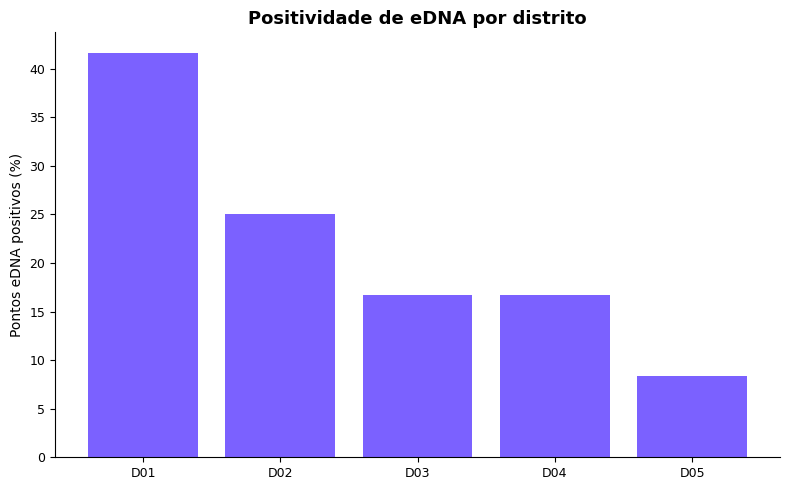

Salvo: /content/outputs_one_health/figures/01_edna_por_distrito.png


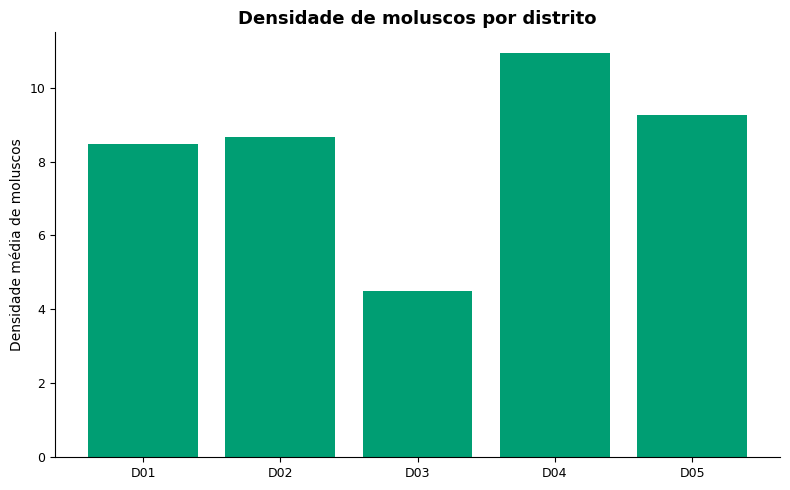

Salvo: /content/outputs_one_health/figures/02_moluscos_por_distrito.png


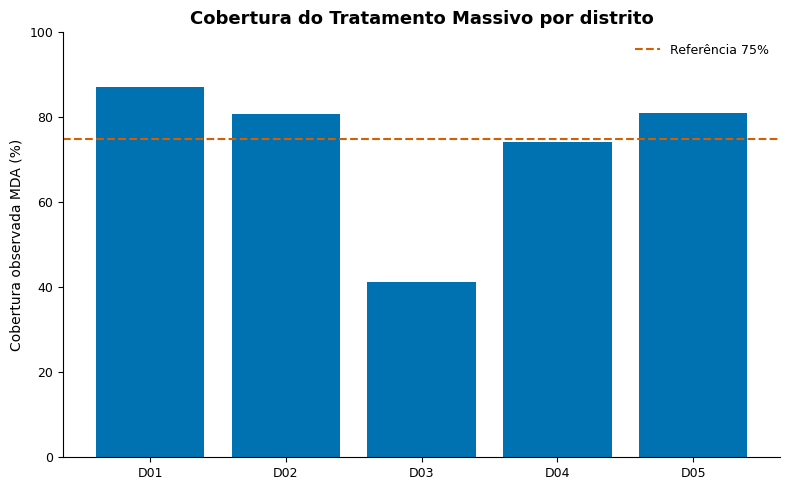

Salvo: /content/outputs_one_health/figures/03_cobertura_mda.png


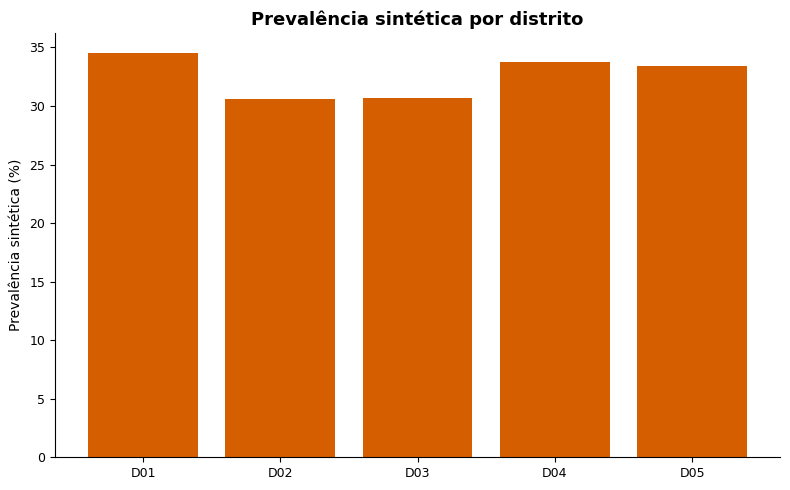

Salvo: /content/outputs_one_health/figures/04_prevalencia_por_distrito.png


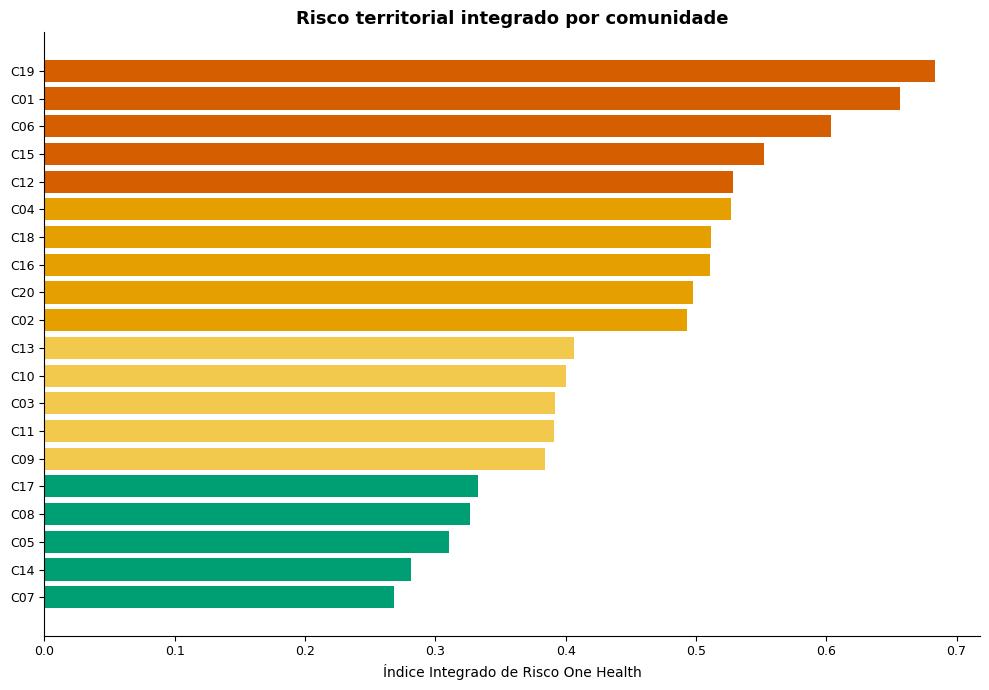

Salvo: /content/outputs_one_health/figures/05_indice_one_health_comunidades.png


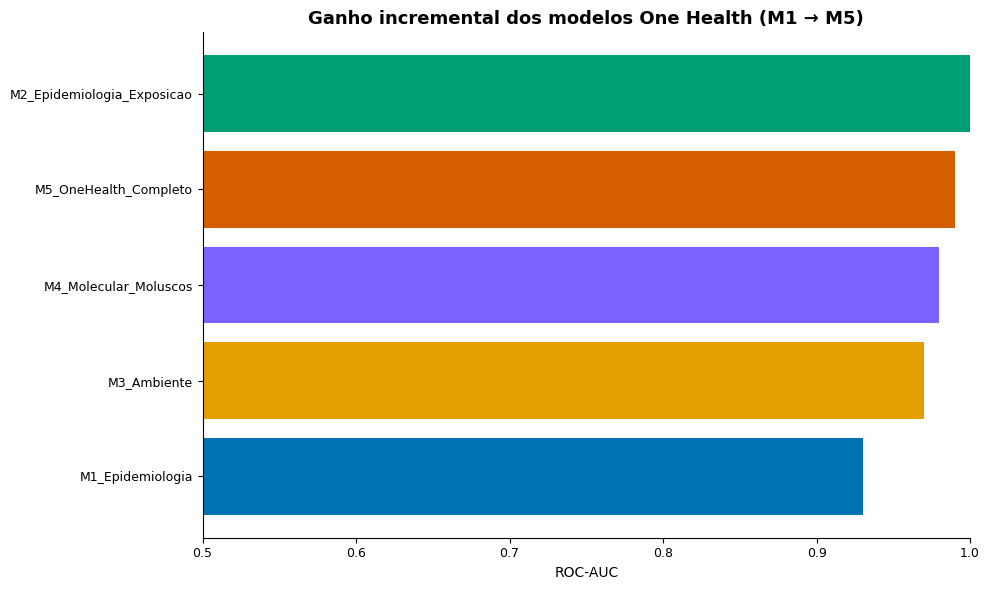

Salvo: /content/outputs_one_health/figures/06_modelos_incrementais_auc.png


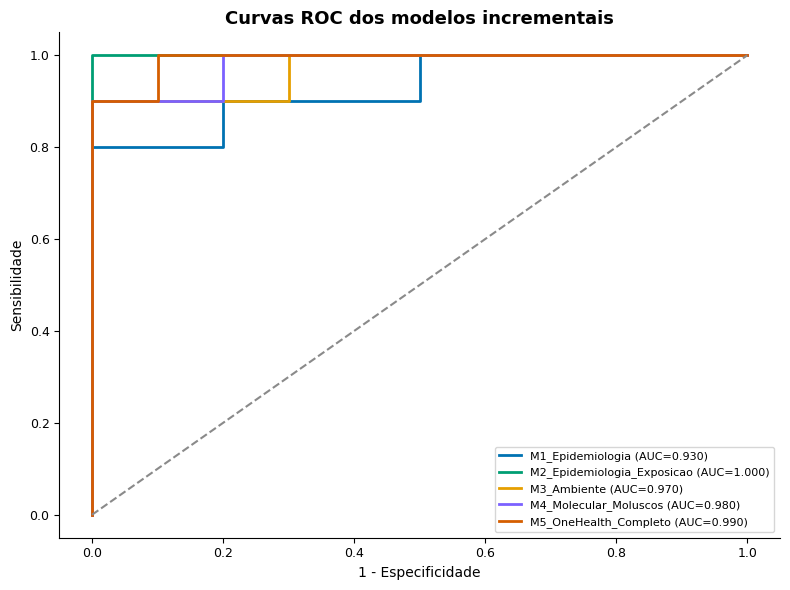

Salvo: /content/outputs_one_health/figures/07_curvas_roc_incrementais.png


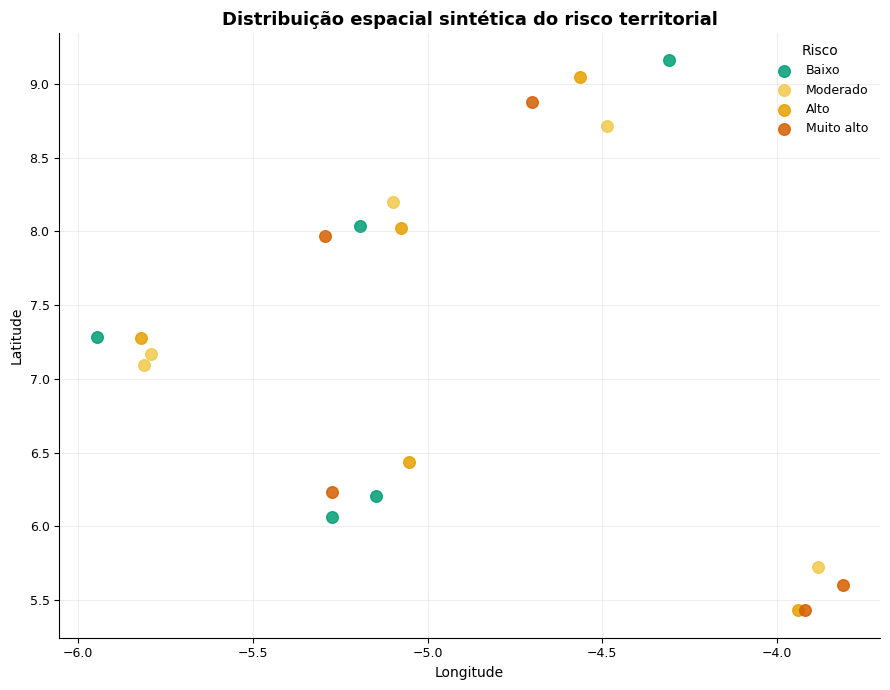

Salvo: /content/outputs_one_health/figures/08_mapa_risco_territorial.png


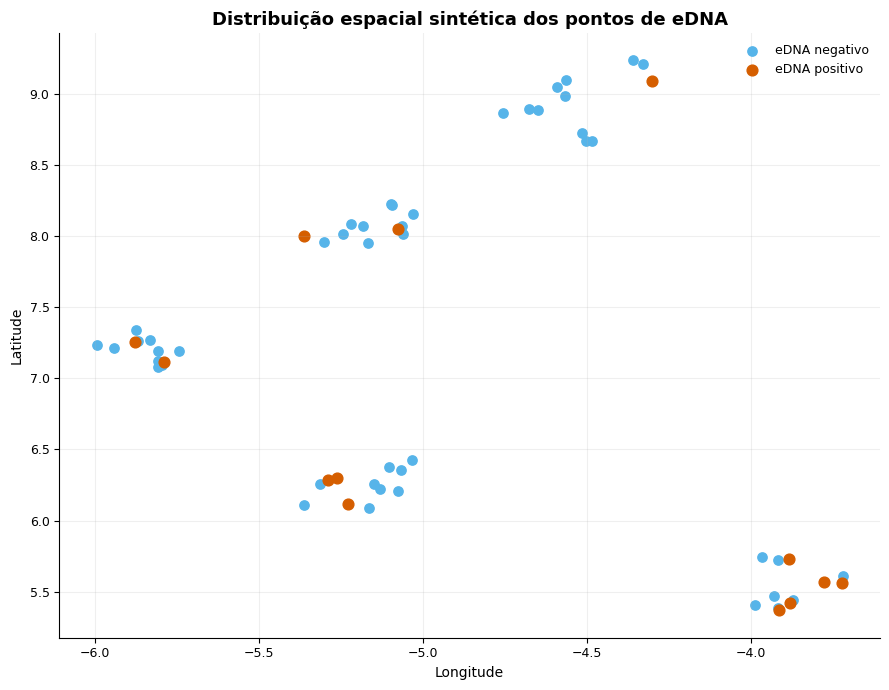

Salvo: /content/outputs_one_health/figures/09_mapa_edna.png


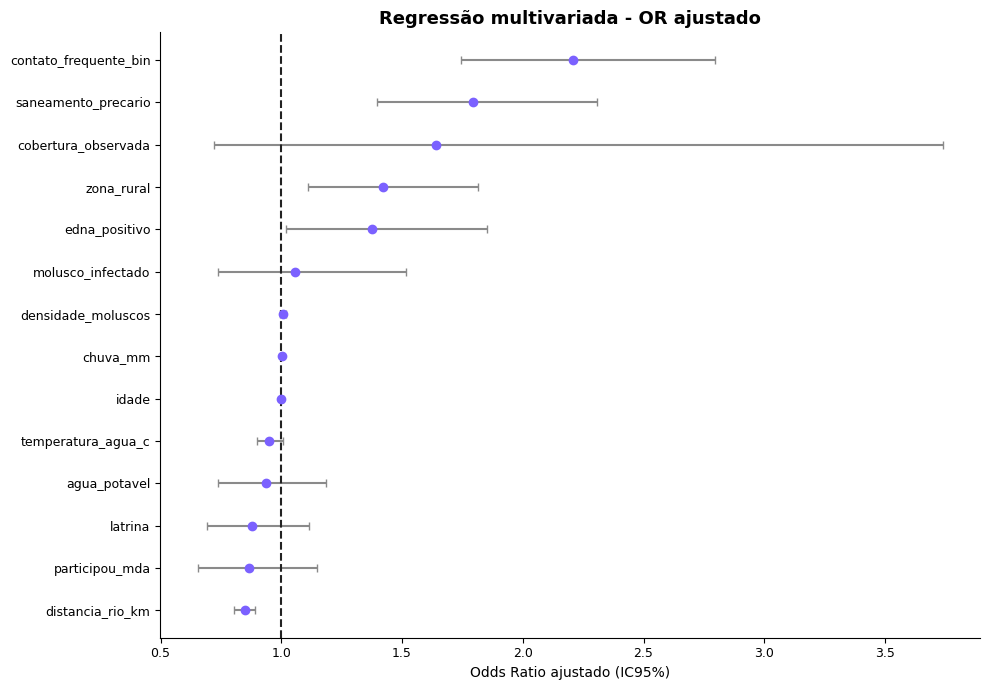

Salvo: /content/outputs_one_health/figures/10_forest_or_ajustado.png


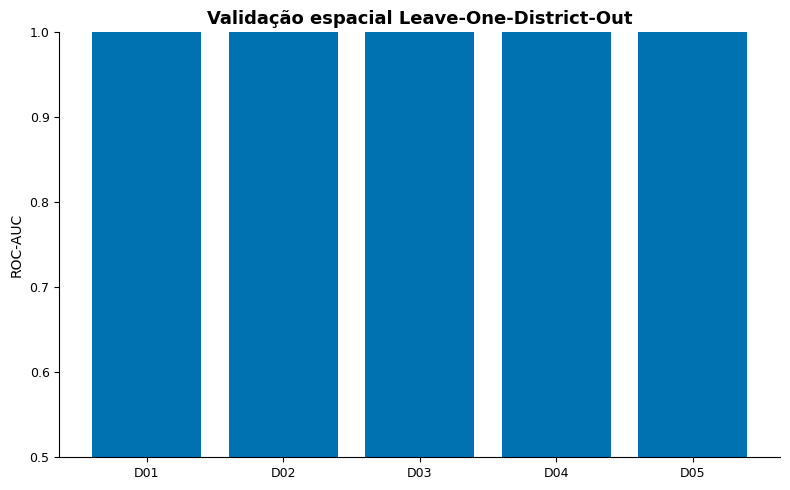

Salvo: /content/outputs_one_health/figures/11_validacao_distritos.png


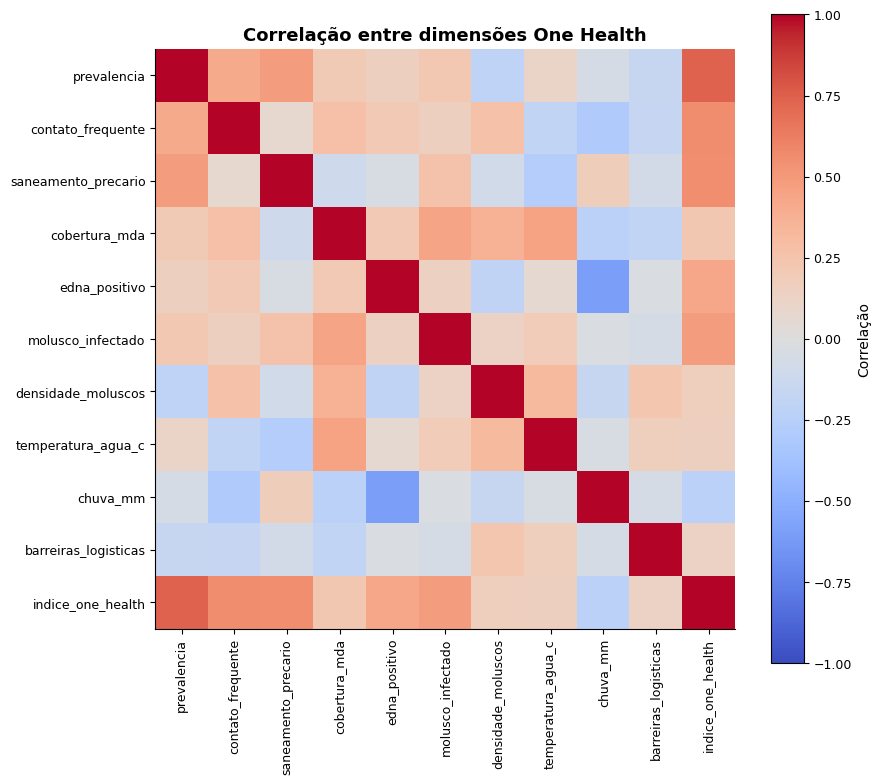

Salvo: /content/outputs_one_health/figures/12_correlacao_dimensoes_one_health.png

SEGUNDA ETAPA CONCLUÍDA

Base individual expandida: 1500 crianças
Comunidades: 20
Escolas: 40
Pontos hídricos: 60
eDNA positivo: 21.7% dos pontos
Moluscos infectados: 13.3% dos pontos

Modelos incrementais M1 → M5:
                    modelo  ROC_AUC  PR_AUC  ganho_auc_vs_M1
          M1_Epidemiologia     0.93  0.9485             0.00
               M3_Ambiente     0.97  0.9769             0.04
     M4_Molecular_Moluscos     0.98  0.9833             0.05
     M5_OneHealth_Completo     0.99  0.9909             0.06
M2_Epidemiologia_Exposicao     1.00  1.0000             0.07

Melhor modelo territorial por ROC-AUC:
M2_Epidemiologia_Exposicao | ROC-AUC=1.0000 | PR-AUC=1.0000

Workbook final:
/content/outputs_one_health/segunda_etapa_one_health_resultados.xlsx

Gráficos:
/content/outputs_one_health/figures

Arquivos CSV principais:
- /content/outputs_one_health/base_1500_one_health_expandida.csv
- /content/o

In [2]:
# ============================================================
# SEGUNDA ETAPA - MODELO INTEGRADO ONE HEALTH PARA ESQUISTOSSOMOSE
# Base existente: 1.500 crianças
# Script ÚNICO - Compatível com Google Colab
# ============================================================
#
# O script parte da base individual já existente e adiciona, de forma sintética:
# - estrutura hierárquica: escola -> comunidade -> distrito;
# - dados ambientais físico-químicos por ponto hídrico;
# - dados de moluscos hospedeiros;
# - dados de eDNA/PCR/Ct/Cq/replicatas;
# - dados de Tratamento Massivo (MDA);
# - dados qualitativos/programáticos;
# - coordenadas geográficas;
# - risco de circulação ambiental;
# - risco territorial de transmissão;
# - regressão multivariada com OR ajustado;
# - modelo multinível (GEE por comunidade);
# - modelos incrementais M1 -> M5;
# - validação espacial Leave-One-District-Out;
# - Índice Integrado de Risco One Health;
# - gráficos correspondentes.
#
# IMPORTANTE:
# Todos os novos dados gerados nesta etapa são SINTÉTICOS e servem
# exclusivamente como prova de conceito metodológica/computacional.
# ============================================================

# ------------------------------------------------------------
# 0. INSTALAÇÃO OPCIONAL NO COLAB
# Descomente a linha abaixo caso statsmodels/openpyxl não estejam instalados.
# ------------------------------------------------------------
# !pip install -q pandas numpy scipy scikit-learn statsmodels openpyxl matplotlib

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.stats import chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve
)
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

BASE_DIR = Path("/content")
OUTPUT_DIR = BASE_DIR / "outputs_one_health"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Nome preferencial do arquivo
ARQUIVO_EXCEL = BASE_DIR / "base_sintetica_esquistossomose_1500.xlsx"

# Busca automática caso o nome seja diferente
if not ARQUIVO_EXCEL.exists():
    candidatos = [
        p for p in BASE_DIR.glob("*.xlsx")
        if not p.name.startswith("~$")
    ]
    candidatos_1500 = [
        p for p in candidatos
        if "1500" in p.name.lower()
    ]

    if candidatos_1500:
        ARQUIVO_EXCEL = candidatos_1500[0]
    elif candidatos:
        ARQUIVO_EXCEL = candidatos[0]
    else:
        raise FileNotFoundError(
            "Nenhum arquivo Excel foi encontrado em /content. "
            "Faça upload da base de 1.500 registros."
        )

print("=" * 85)
print("SEGUNDA ETAPA - MODELO INTEGRADO ONE HEALTH")
print("=" * 85)
print(f"Base utilizada: {ARQUIVO_EXCEL}")

# ============================================================
# 2. CARREGAR BASE ORIGINAL
# ============================================================

df = pd.read_excel(ARQUIVO_EXCEL)

print(f"\nRegistros carregados: {len(df)}")
print(f"Variáveis originais: {df.shape[1]}")

if len(df) != 1500:
    print(
        f"ATENÇÃO: a base possui {len(df)} registros. "
        "O pipeline continuará, mas foi planejado para 1.500."
    )

colunas_minimas = [
    "paciente_id",
    "idade",
    "sexo",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "esquistossomose_confirmada"
]

faltantes = [c for c in colunas_minimas if c not in df.columns]
if faltantes:
    raise ValueError(
        "A base não contém todas as colunas necessárias:\n"
        + "\n".join(f"- {c}" for c in faltantes)
    )

# ============================================================
# 3. ESTRUTURA HIERÁRQUICA
# ============================================================

# Mantemos as 1.500 crianças e criamos níveis territoriais.
N_DISTRITOS = 5
N_COMUNIDADES = 20
N_ESCOLAS = 40
N_PONTOS_AGUA = 60

distritos = [f"D{i:02d}" for i in range(1, N_DISTRITOS + 1)]
comunidades = [f"C{i:02d}" for i in range(1, N_COMUNIDADES + 1)]
escolas = [f"E{i:02d}" for i in range(1, N_ESCOLAS + 1)]
pontos_agua = [f"A{i:03d}" for i in range(1, N_PONTOS_AGUA + 1)]

# País único desta prova de conceito
PAIS = "Costa_do_Marfim"

# Coordenadas sintéticas aproximadas dentro de uma área compatível
# com o contexto geográfico do projeto (não representam locais reais).
centros_distritos = {
    "D01": (5.45, -4.10),
    "D02": (6.20, -5.10),
    "D03": (7.10, -5.80),
    "D04": (8.00, -5.20),
    "D05": (9.00, -4.50),
}

# Comunidade -> distrito
community_to_district = {}
for i, comunidade in enumerate(comunidades):
    community_to_district[comunidade] = distritos[i % N_DISTRITOS]

# Escola -> comunidade
school_to_community = {}
for i, escola in enumerate(escolas):
    school_to_community[escola] = comunidades[i % N_COMUNIDADES]

# Distribuição das crianças pelas escolas
df["escola_id"] = rng.choice(escolas, size=len(df))
df["comunidade_id"] = df["escola_id"].map(school_to_community)
df["distrito_id"] = df["comunidade_id"].map(community_to_district)
df["pais"] = PAIS

# ============================================================
# 4. COORDENADAS DE COMUNIDADES E ESCOLAS
# ============================================================

community_rows = []

for comunidade in comunidades:
    distrito = community_to_district[comunidade]
    lat0, lon0 = centros_distritos[distrito]

    lat = lat0 + rng.normal(0, 0.16)
    lon = lon0 + rng.normal(0, 0.16)

    community_rows.append({
        "comunidade_id": comunidade,
        "distrito_id": distrito,
        "pais": PAIS,
        "latitude_comunidade": lat,
        "longitude_comunidade": lon,
        "densidade_populacional": float(
            np.clip(rng.lognormal(mean=4.3, sigma=0.55), 30, 1500)
        ),
        "cobertura_vegetal_pct": float(
            np.clip(rng.normal(48, 18), 5, 95)
        ),
        "uso_solo_agricola_pct": float(
            np.clip(rng.normal(42, 18), 2, 90)
        )
    })

community_df = pd.DataFrame(community_rows)

school_rows = []

for escola in escolas:
    comunidade = school_to_community[escola]
    c = community_df.loc[
        community_df["comunidade_id"] == comunidade
    ].iloc[0]

    school_rows.append({
        "escola_id": escola,
        "comunidade_id": comunidade,
        "distrito_id": c["distrito_id"],
        "latitude_escola": c["latitude_comunidade"] + rng.normal(0, 0.025),
        "longitude_escola": c["longitude_comunidade"] + rng.normal(0, 0.025)
    })

school_df = pd.DataFrame(school_rows)

# ============================================================
# 5. PONTOS HÍDRICOS E DADOS AMBIENTAIS
# ============================================================

water_rows = []

tipos_agua = ["Rio", "Lago", "Lagoa", "Canal"]
uso_pop = ["Baixo", "Moderado", "Alto"]

for i, ponto in enumerate(pontos_agua):
    comunidade = comunidades[i % N_COMUNIDADES]

    c = community_df.loc[
        community_df["comunidade_id"] == comunidade
    ].iloc[0]

    temperatura = float(np.clip(rng.normal(27.0, 2.2), 20, 34))
    ph = float(np.clip(rng.normal(7.0, 0.65), 5.0, 9.2))
    turbidez = float(np.clip(rng.lognormal(3.1, 0.55), 3, 150))
    condutividade = float(np.clip(rng.normal(230, 75), 40, 550))
    oxigenio = float(np.clip(rng.normal(6.1, 1.3), 1.5, 10))
    vegetacao_margem = float(np.clip(rng.normal(55, 22), 0, 100))
    sazonal = int(rng.binomial(1, 0.28))

    water_rows.append({
        "ponto_agua_id": ponto,
        "comunidade_id": comunidade,
        "distrito_id": c["distrito_id"],
        "latitude_agua": c["latitude_comunidade"] + rng.normal(0, 0.04),
        "longitude_agua": c["longitude_comunidade"] + rng.normal(0, 0.04),
        "tipo_corpo_hidrico": rng.choice(tipos_agua, p=[0.45, 0.15, 0.20, 0.20]),
        "uso_populacao": rng.choice(uso_pop, p=[0.20, 0.45, 0.35]),
        "sazonal": sazonal,
        "temperatura_agua_c": temperatura,
        "ph": ph,
        "turbidez_ntu": turbidez,
        "condutividade_us_cm": condutividade,
        "oxigenio_dissolvido_mg_l": oxigenio,
        "vegetacao_margem_pct": vegetacao_margem,
        "atividade_humana_entorno_score": float(
            np.clip(rng.normal(6.0, 2.0), 0, 10)
        )
    })

water_df = pd.DataFrame(water_rows)

# ============================================================
# 6. DADOS DE MOLUSCOS HOSPEDEIROS
# ============================================================

snail_rows = []

for _, w in water_df.iterrows():

    uso_alto = int(w["uso_populacao"] == "Alto")

    p_presenca = expit(
        -0.7
        + 0.08 * (w["temperatura_agua_c"] - 25)
        + 0.012 * w["vegetacao_margem_pct"]
        + 0.25 * uso_alto
        - 0.004 * w["turbidez_ntu"]
    )

    molusco_presente = int(rng.binomial(1, p_presenca))

    densidade = (
        float(np.clip(rng.gamma(2.4, 6.0), 1, 80))
        if molusco_presente
        else 0.0
    )

    especie = (
        rng.choice(["Bulinus spp.", "Biomphalaria spp."])
        if molusco_presente
        else "Não observado"
    )

    p_infectado = np.clip(
        0.03
        + 0.13 * molusco_presente
        + 0.004 * densidade,
        0,
        0.70
    )

    infectado = int(rng.binomial(1, p_infectado))

    snail_rows.append({
        "ponto_agua_id": w["ponto_agua_id"],
        "comunidade_id": w["comunidade_id"],
        "distrito_id": w["distrito_id"],
        "especie_molusco": especie,
        "molusco_presente": molusco_presente,
        "quantidade_encontrada": int(round(densidade * rng.uniform(2, 5))),
        "densidade_moluscos": densidade,
        "molusco_infectado": infectado,
        "metodo_infeccao": (
            rng.choice(["Microscopia", "PCR", "Exposição à luz"])
            if molusco_presente
            else "Não aplicável"
        )
    })

snail_df = pd.DataFrame(snail_rows)

# ============================================================
# 7. eDNA / PCR / Ct-Cq / REPLICATAS
# ============================================================

edna_rows = []

for _, w in water_df.iterrows():

    s = snail_df.loc[
        snail_df["ponto_agua_id"] == w["ponto_agua_id"]
    ].iloc[0]

    p_edna = expit(
        -2.0
        + 1.4 * s["molusco_infectado"]
        + 0.018 * s["densidade_moluscos"]
        + 0.35 * int(w["uso_populacao"] == "Alto")
        + 0.015 * (w["temperatura_agua_c"] - 25)
    )

    edna_positivo = int(rng.binomial(1, p_edna))

    cq = (
        float(np.clip(rng.normal(30.5 - 3.5 * p_edna, 2.5), 18, 39))
        if edna_positivo
        else np.nan
    )

    edna_rows.append({
        "ponto_agua_id": w["ponto_agua_id"],
        "comunidade_id": w["comunidade_id"],
        "distrito_id": w["distrito_id"],
        "data_coleta": (
            pd.Timestamp("2026-06-01")
            + pd.Timedelta(days=int(rng.integers(0, 120)))
        ),
        "volume_agua_ml": int(rng.choice([500, 1000, 2000])),
        "metodo_filtracao": rng.choice(["Membrana", "Cartucho"]),
        "tipo_filtro": rng.choice(["0.22 µm", "0.45 µm"]),
        "conservacao": rng.choice(["Etanol", "Congelado", "Buffer de lise"]),
        "dna_concentracao_ng_ul": float(
            np.clip(rng.lognormal(1.7, 0.5), 0.2, 90)
        ),
        "dna_qualidade_260_280": float(
            np.clip(rng.normal(1.85, 0.12), 1.4, 2.2)
        ),
        "edna_positivo": edna_positivo,
        "cq_value": cq,
        "replicatas_positivas": (
            int(rng.integers(1, 4))
            if edna_positivo
            else 0
        ),
        "especie_alvo": (
            "Schistosoma spp."
            if edna_positivo
            else "Não detectado"
        ),
        "controle_positivo_ok": 1,
        "controle_negativo_ok": 1
    })

edna_df = pd.DataFrame(edna_rows)

# ============================================================
# 8. TRATAMENTO MASSIVO (MDA) POR DISTRITO
# ============================================================

mda_rows = []

for distrito in distritos:

    elegiveis = int(
        (df["distrito_id"] == distrito).sum()
    )

    cobertura_programatica = float(
        np.clip(rng.normal(0.76, 0.10), 0.45, 0.97)
    )

    tratados = int(
        round(elegiveis * cobertura_programatica * rng.uniform(0.88, 1.02))
    )

    tratados = min(tratados, elegiveis)

    mda_rows.append({
        "distrito_id": distrito,
        "populacao_alvo": "Crianças em idade escolar",
        "medicamento": "Praziquantel",
        "frequencia_administracao": rng.choice(
            ["Anual", "Bienal"],
            p=[0.75, 0.25]
        ),
        "criancas_elegiveis": elegiveis,
        "criancas_tratadas": tratados,
        "cobertura_programatica": cobertura_programatica,
        "cobertura_observada": tratados / elegiveis if elegiveis else np.nan,
        "recusas_ausencias_pct": float(
            np.clip(rng.normal(8, 4), 0, 25)
        ),
        "dificuldade_implementacao_score": float(
            np.clip(rng.normal(4.0, 2.0), 0, 10)
        ),
        "mobilizacao_comunitaria_score": float(
            np.clip(rng.normal(6.8, 1.7), 0, 10)
        ),
        "participacao_escolas_score": float(
            np.clip(rng.normal(7.5, 1.4), 0, 10)
        ),
        "participacao_saude_score": float(
            np.clip(rng.normal(7.2, 1.5), 0, 10)
        ),
        "mecanismo_monitorizacao": rng.choice(
            ["Relatório distrital", "Registro escolar", "Sistema eletrônico"]
        )
    })

mda_df = pd.DataFrame(mda_rows)

# ============================================================
# 9. DADOS QUALITATIVOS / PROGRAMÁTICOS
# ============================================================

qual_rows = []

for comunidade in comunidades:

    distrito = community_to_district[comunidade]

    qual_rows.append({
        "comunidade_id": comunidade,
        "distrito_id": distrito,
        "conhecimento_comunidade_score": float(
            np.clip(rng.normal(5.5, 1.8), 0, 10)
        ),
        "percepcao_risco_score": float(
            np.clip(rng.normal(5.8, 1.8), 0, 10)
        ),
        "barreiras_culturais_score": float(
            np.clip(rng.normal(4.0, 2.0), 0, 10)
        ),
        "barreiras_logisticas_score": float(
            np.clip(rng.normal(4.8, 2.0), 0, 10)
        ),
        "acesso_diagnostico_score": float(
            np.clip(rng.normal(6.0, 1.8), 0, 10)
        ),
        "acesso_tratamento_score": float(
            np.clip(rng.normal(6.3, 1.7), 0, 10)
        ),
        "articulacao_saude_educacao_score": float(
            np.clip(rng.normal(6.7, 1.5), 0, 10)
        )
    })

qual_df = pd.DataFrame(qual_rows)

# ============================================================
# 10. ASSOCIAR CADA CRIANÇA AO PONTO HÍDRICO MAIS PRÓXIMO
# ============================================================

# Coordenadas da escola por criança
df = df.merge(
    school_df,
    on=["escola_id", "comunidade_id", "distrito_id"],
    how="left"
)

# Dados da comunidade
df = df.merge(
    community_df,
    on=["comunidade_id", "distrito_id", "pais"],
    how="left"
)

# Seleção de ponto de água da mesma comunidade
water_by_community = {
    c: water_df.loc[
        water_df["comunidade_id"] == c,
        "ponto_agua_id"
    ].tolist()
    for c in comunidades
}

df["ponto_agua_id"] = [
    rng.choice(water_by_community[c])
    for c in df["comunidade_id"]
]

# Une ambiente, moluscos, eDNA, MDA e qualitativo
df = df.merge(
    water_df,
    on=["ponto_agua_id", "comunidade_id", "distrito_id"],
    how="left"
)

df = df.merge(
    snail_df,
    on=["ponto_agua_id", "comunidade_id", "distrito_id"],
    how="left"
)

df = df.merge(
    edna_df[
        [
            "ponto_agua_id",
            "comunidade_id",
            "distrito_id",
            "edna_positivo",
            "cq_value",
            "replicatas_positivas"
        ]
    ],
    on=["ponto_agua_id", "comunidade_id", "distrito_id"],
    how="left"
)

df = df.merge(
    mda_df,
    on="distrito_id",
    how="left"
)

df = df.merge(
    qual_df,
    on=["comunidade_id", "distrito_id"],
    how="left"
)

# ============================================================
# 11. VARIÁVEIS INDIVIDUAIS COMPLEMENTARES
# ============================================================

# Histórico MDA individual coerente com cobertura distrital
df["participou_mda"] = rng.binomial(
    1,
    np.clip(df["cobertura_observada"].fillna(0.7), 0, 1)
)

df["numero_doses_mda"] = np.where(
    df["participou_mda"] == 1,
    rng.integers(1, 5, size=len(df)),
    0
)

df["meses_desde_ultima_dose"] = np.where(
    df["participou_mda"] == 1,
    rng.integers(1, 36, size=len(df)),
    np.nan
)

df["agua_potavel"] = rng.binomial(
    1,
    np.clip(
        0.70
        - 0.20 * df["saneamento_precario"].fillna(0),
        0.30,
        0.95
    )
)

df["latrina"] = rng.binomial(
    1,
    np.clip(
        0.72
        - 0.25 * df["saneamento_precario"].fillna(0),
        0.25,
        0.95
    )
)

df["higiene_score"] = np.clip(
    rng.normal(6.0, 1.8, size=len(df)),
    0,
    10
)

df["conhecimento_esquistossomose_score"] = np.clip(
    rng.normal(5.7, 1.9, size=len(df)),
    0,
    10
)

df["percepcao_risco_individual_score"] = np.clip(
    rng.normal(5.5, 2.0, size=len(df)),
    0,
    10
)

# ============================================================
# 12. RISCO DE CIRCULAÇÃO AMBIENTAL
# ============================================================

# Normalizações
water_for_risk = water_df.copy()

water_for_risk = water_for_risk.merge(
    snail_df[
        [
            "ponto_agua_id",
            "densidade_moluscos",
            "molusco_infectado"
        ]
    ],
    on="ponto_agua_id",
    how="left"
)

water_for_risk = water_for_risk.merge(
    edna_df[
        [
            "ponto_agua_id",
            "edna_positivo",
            "replicatas_positivas"
        ]
    ],
    on="ponto_agua_id",
    how="left"
)

scaler_env = MinMaxScaler()

env_components = pd.DataFrame({
    "edna": water_for_risk["edna_positivo"].fillna(0),
    "molusco_infectado": water_for_risk["molusco_infectado"].fillna(0),
    "densidade_moluscos": water_for_risk["densidade_moluscos"].fillna(0),
    "temperatura": water_for_risk["temperatura_agua_c"].fillna(
        water_for_risk["temperatura_agua_c"].median()
    ),
    "turbidez": water_for_risk["turbidez_ntu"].fillna(
        water_for_risk["turbidez_ntu"].median()
    ),
    "uso_humano": water_for_risk["uso_populacao"].map({
        "Baixo": 0,
        "Moderado": 0.5,
        "Alto": 1
    }).fillna(0)
})

env_norm = pd.DataFrame(
    scaler_env.fit_transform(env_components),
    columns=env_components.columns
)

water_for_risk["indice_circulacao_ambiental"] = (
    0.30 * env_norm["edna"]
    + 0.25 * env_norm["molusco_infectado"]
    + 0.15 * env_norm["densidade_moluscos"]
    + 0.10 * env_norm["temperatura"]
    + 0.05 * env_norm["turbidez"]
    + 0.15 * env_norm["uso_humano"]
)

water_for_risk["estrato_circulacao_ambiental"] = pd.qcut(
    water_for_risk["indice_circulacao_ambiental"],
    q=4,
    labels=["Baixo", "Moderado", "Alto", "Muito alto"],
    duplicates="drop"
)

# ============================================================
# 13. TABELA TERRITORIAL
# ============================================================

territorio = df.groupby(
    ["pais", "distrito_id", "comunidade_id"],
    as_index=False
).agg(
    n_criancas=("paciente_id", "count"),
    prevalencia=("esquistossomose_confirmada", "mean"),
    contato_frequente=("contato_agua", lambda s: (s == 2).mean()),
    saneamento_precario=("saneamento_precario", "mean"),
    agua_potavel=("agua_potavel", "mean"),
    cobertura_mda=("cobertura_observada", "mean"),
    edna_positivo=("edna_positivo", "mean"),
    molusco_infectado=("molusco_infectado", "mean"),
    densidade_moluscos=("densidade_moluscos", "mean"),
    temperatura_agua_c=("temperatura_agua_c", "mean"),
    turbidez_ntu=("turbidez_ntu", "mean"),
    chuva_mm=("chuva_mm", "mean"),
    barreiras_logisticas=("barreiras_logisticas_score", "mean"),
    conhecimento_comunidade=("conhecimento_comunidade_score", "mean"),
    latitude=("latitude_comunidade", "mean"),
    longitude=("longitude_comunidade", "mean")
)

# ============================================================
# 14. ÍNDICE INTEGRADO DE RISCO ONE HEALTH
# ============================================================

territorial_components = pd.DataFrame({
    "epidemiologia": territorio["prevalencia"],
    "exposicao": territorio["contato_frequente"],
    "vulnerabilidade_saneamento": territorio["saneamento_precario"],
    "molecular": territorio["edna_positivo"],
    "moluscos": (
        territorio["molusco_infectado"]
        + territorio["densidade_moluscos"]
        / max(territorio["densidade_moluscos"].max(), 1)
    ) / 2,
    "ambiente": (
        territorio["temperatura_agua_c"]
        / max(territorio["temperatura_agua_c"].max(), 1)
        + territorio["chuva_mm"]
        / max(territorio["chuva_mm"].max(), 1)
    ) / 2,
    "programatico": 1 - territorio["cobertura_mda"],
    "barreiras": territorio["barreiras_logisticas"] / 10
})

scaler_risk = MinMaxScaler()

territorial_norm = pd.DataFrame(
    scaler_risk.fit_transform(territorial_components),
    columns=territorial_components.columns
)

pesos = {
    "epidemiologia": 0.22,
    "exposicao": 0.13,
    "vulnerabilidade_saneamento": 0.12,
    "molecular": 0.15,
    "moluscos": 0.15,
    "ambiente": 0.08,
    "programatico": 0.08,
    "barreiras": 0.07
}

territorio["indice_one_health"] = sum(
    territorial_norm[c] * w
    for c, w in pesos.items()
)

territorio["estrato_risco_territorial"] = pd.qcut(
    territorio["indice_one_health"],
    q=4,
    labels=["Baixo", "Moderado", "Alto", "Muito alto"],
    duplicates="drop"
)

territorio["alto_risco_territorial"] = (
    territorio["estrato_risco_territorial"]
    .isin(["Alto", "Muito alto"])
    .astype(int)
)

# ============================================================
# 15. REGRESSÃO LOGÍSTICA MULTIVARIADA - OR AJUSTADO
# ============================================================

df["contato_frequente_bin"] = (
    df["contato_agua"] == 2
).astype(int)

reg_features = [
    "idade",
    "zona_rural",
    "contato_frequente_bin",
    "saneamento_precario",
    "distancia_rio_km",
    "agua_potavel",
    "latrina",
    "participou_mda",
    "cobertura_observada",
    "edna_positivo",
    "molusco_infectado",
    "densidade_moluscos",
    "temperatura_agua_c",
    "chuva_mm"
]

reg_data = df[
    reg_features + ["esquistossomose_confirmada"]
].dropna().copy()

X_reg = sm.add_constant(
    reg_data[reg_features]
)

y_reg = reg_data["esquistossomose_confirmada"]

modelo_logit = sm.Logit(
    y_reg,
    X_reg
).fit(
    disp=False,
    maxiter=200
)

conf = modelo_logit.conf_int()

or_ajustado = pd.DataFrame({
    "variavel": modelo_logit.params.index,
    "beta": modelo_logit.params.values,
    "p_valor": modelo_logit.pvalues.values,
    "OR_ajustado": np.exp(modelo_logit.params.values),
    "IC95_inf": np.exp(conf[0].values),
    "IC95_sup": np.exp(conf[1].values)
})

# ============================================================
# 16. MODELO MULTINÍVEL / GEE POR COMUNIDADE
# ============================================================

formula_gee = """
esquistossomose_confirmada ~
idade +
zona_rural +
contato_frequente_bin +
saneamento_precario +
distancia_rio_km +
agua_potavel +
latrina +
participou_mda +
cobertura_observada +
edna_positivo +
molusco_infectado +
densidade_moluscos
"""

gee_model = smf.gee(
    formula=formula_gee,
    groups="comunidade_id",
    data=df,
    family=sm.families.Binomial()
).fit()

gee_result = pd.DataFrame({
    "variavel": gee_model.params.index,
    "beta": gee_model.params.values,
    "p_valor": gee_model.pvalues.values,
    "OR_aproximado": np.exp(gee_model.params.values)
})

# ============================================================
# 17. MODELOS INCREMENTAIS M1 -> M5
# ============================================================

# Desfecho territorial: alto/muito alto
y_t = territorio["alto_risco_territorial"]

model_sets = {
    "M1_Epidemiologia": [
        "prevalencia"
    ],

    "M2_Epidemiologia_Exposicao": [
        "prevalencia",
        "contato_frequente",
        "saneamento_precario"
    ],

    "M3_Ambiente": [
        "prevalencia",
        "contato_frequente",
        "saneamento_precario",
        "temperatura_agua_c",
        "turbidez_ntu",
        "chuva_mm"
    ],

    "M4_Molecular_Moluscos": [
        "prevalencia",
        "contato_frequente",
        "saneamento_precario",
        "temperatura_agua_c",
        "turbidez_ntu",
        "chuva_mm",
        "edna_positivo",
        "molusco_infectado",
        "densidade_moluscos"
    ],

    "M5_OneHealth_Completo": [
        "prevalencia",
        "contato_frequente",
        "saneamento_precario",
        "agua_potavel",
        "cobertura_mda",
        "temperatura_agua_c",
        "turbidez_ntu",
        "chuva_mm",
        "edna_positivo",
        "molusco_infectado",
        "densidade_moluscos",
        "barreiras_logisticas",
        "conhecimento_comunidade"
    ]
}

# Validação espacial Leave-One-District-Out
groups = territorio["distrito_id"]

n_splits = min(
    len(territorio["distrito_id"].unique()),
    5
)

cv = GroupKFold(
    n_splits=n_splits
)

incremental_rows = []
incremental_predictions = {}

for nome, feats in model_sets.items():

    X_t = territorio[feats].copy()

    X_t = X_t.fillna(
        X_t.median(numeric_only=True)
    )

    model = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    p = cross_val_predict(
        model,
        X_t,
        y_t,
        cv=cv,
        groups=groups,
        method="predict_proba"
    )[:, 1]

    pred = (p >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_t,
        pred
    ).ravel()

    incremental_predictions[nome] = p

    incremental_rows.append({
        "modelo": nome,
        "ROC_AUC": roc_auc_score(y_t, p),
        "PR_AUC": average_precision_score(y_t, p),
        "acuracia": accuracy_score(y_t, pred),
        "sensibilidade": recall_score(y_t, pred, zero_division=0),
        "especificidade": tn / (tn + fp) if (tn + fp) else np.nan,
        "precisao": precision_score(y_t, pred, zero_division=0),
        "F1": f1_score(y_t, pred, zero_division=0),
        "Brier": brier_score_loss(y_t, p)
    })

incremental = pd.DataFrame(
    incremental_rows
).sort_values(
    "ROC_AUC",
    ascending=True
).reset_index(drop=True)

baseline_auc = incremental.loc[
    incremental["modelo"] == "M1_Epidemiologia",
    "ROC_AUC"
].iloc[0]

incremental["ganho_auc_vs_M1"] = (
    incremental["ROC_AUC"]
    - baseline_auc
)

# ============================================================
# 18. VALIDAÇÃO LEAVE-ONE-DISTRICT-OUT DETALHADA DO M5
# ============================================================

m5_features = model_sets["M5_OneHealth_Completo"]

valid_rows = []

for distrito_teste in sorted(
    territorio["distrito_id"].unique()
):

    train = territorio[
        territorio["distrito_id"] != distrito_teste
    ]

    test = territorio[
        territorio["distrito_id"] == distrito_teste
    ]

    if test["alto_risco_territorial"].nunique() < 2:
        continue

    X_train = train[m5_features].fillna(
        train[m5_features].median(numeric_only=True)
    )

    y_train = train["alto_risco_territorial"]

    X_test = test[m5_features].copy()

    for c in m5_features:
        X_test[c] = X_test[c].fillna(
            train[c].median()
        )

    y_test = test["alto_risco_territorial"]

    model = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    p = model.predict_proba(
        X_test
    )[:, 1]

    pred = (p >= 0.5).astype(int)

    valid_rows.append({
        "distrito_teste": distrito_teste,
        "n_comunidades": len(test),
        "ROC_AUC": roc_auc_score(y_test, p),
        "PR_AUC": average_precision_score(y_test, p),
        "acuracia": accuracy_score(y_test, pred)
    })

validacao_distritos = pd.DataFrame(
    valid_rows
)

# ============================================================
# 19. ANÁLISE GEOESPACIAL SIMPLIFICADA
# ============================================================

# Distância aproximada comunidade -> ponto hídrico associado
# Fórmula de Haversine
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)

    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(phi1)
        * np.cos(phi2)
        * np.sin(dlambda / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

df["dist_escola_agua_geo_km"] = haversine_km(
    df["latitude_escola"],
    df["longitude_escola"],
    df["latitude_agua"],
    df["longitude_agua"]
)

# Hotspot territorial = quartil superior do índice
limiar_hotspot = territorio[
    "indice_one_health"
].quantile(0.75)

territorio["hotspot_one_health"] = (
    territorio["indice_one_health"]
    >= limiar_hotspot
).astype(int)

# ============================================================
# 20. GRÁFICOS
# ============================================================

# Paleta
AZUL = "#0072B2"
AZUL_CLARO = "#56B4E9"
VERDE = "#009E73"
LARANJA = "#E69F00"
VERMELHO = "#D55E00"
ROXO = "#7B61FF"
AMARELO = "#F2C94C"
CINZA = "#8A8A8A"
PRETO = "#222222"

CORES_RISCO = {
    "Baixo": VERDE,
    "Moderado": AMARELO,
    "Alto": LARANJA,
    "Muito alto": VERMELHO
}

# Padrão visual: fundo limpo, títulos consistentes e paleta semântica.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

def salvar(nome):
    caminho = FIG_DIR / nome
    plt.tight_layout()
    plt.savefig(
        caminho,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    plt.close()
    print(f"Salvo: {caminho}")

# ------------------------------------------------------------
# Gráfico 1 - eDNA positivo por distrito
# ------------------------------------------------------------

edna_dist = (
    edna_df.groupby("distrito_id")["edna_positivo"]
    .mean()
    .sort_index()
    * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    edna_dist.index,
    edna_dist.values,
    color=ROXO
)
ax.set_ylabel("Pontos eDNA positivos (%)")
ax.set_title("Positividade de eDNA por distrito")
salvar("01_edna_por_distrito.png")

# ------------------------------------------------------------
# Gráfico 2 - densidade de moluscos por distrito
# ------------------------------------------------------------

snail_dist = (
    snail_df.groupby("distrito_id")["densidade_moluscos"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    snail_dist.index,
    snail_dist.values,
    color=VERDE
)
ax.set_ylabel("Densidade média de moluscos")
ax.set_title("Densidade de moluscos por distrito")
salvar("02_moluscos_por_distrito.png")

# ------------------------------------------------------------
# Gráfico 3 - cobertura MDA
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    mda_df["distrito_id"],
    mda_df["cobertura_observada"] * 100,
    color=AZUL
)
ax.axhline(75, color=VERMELHO, linestyle="--", linewidth=1.5, label="Referência 75%")
ax.set_ylim(0, 100)
ax.set_ylabel("Cobertura observada MDA (%)")
ax.set_title("Cobertura do Tratamento Massivo por distrito")
ax.legend(frameon=False)
salvar("03_cobertura_mda.png")

# ------------------------------------------------------------
# Gráfico 4 - prevalência territorial
# ------------------------------------------------------------

prev_dist = (
    df.groupby("distrito_id")[
        "esquistossomose_confirmada"
    ].mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    prev_dist.index,
    prev_dist.values,
    color=VERMELHO
)
ax.set_ylabel("Prevalência sintética (%)")
ax.set_title("Prevalência sintética por distrito")
salvar("04_prevalencia_por_distrito.png")

# ------------------------------------------------------------
# Gráfico 5 - Índice One Health por comunidade
# ------------------------------------------------------------

territorio_plot = territorio.sort_values(
    "indice_one_health",
    ascending=True
).copy()

cores = [
    CORES_RISCO[str(r)]
    for r in territorio_plot[
        "estrato_risco_territorial"
    ]
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    territorio_plot["comunidade_id"],
    territorio_plot["indice_one_health"],
    color=cores
)
ax.set_xlabel("Índice Integrado de Risco One Health")
ax.set_title("Risco territorial integrado por comunidade")
salvar("05_indice_one_health_comunidades.png")

# ------------------------------------------------------------
# Gráfico 6 - M1 -> M5
# ------------------------------------------------------------

inc_plot = incremental.sort_values(
    "ROC_AUC"
)

fig, ax = plt.subplots(figsize=(10, 6))
cores_m1_m5 = {
    "M1_Epidemiologia": AZUL,
    "M2_Epidemiologia_Exposicao": VERDE,
    "M3_Ambiente": LARANJA,
    "M4_Molecular_Moluscos": ROXO,
    "M5_OneHealth_Completo": VERMELHO
}
ax.barh(
    inc_plot["modelo"],
    inc_plot["ROC_AUC"],
    color=[cores_m1_m5[m] for m in inc_plot["modelo"]]
)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("ROC-AUC")
ax.set_title("Ganho incremental dos modelos One Health (M1 → M5)")
salvar("06_modelos_incrementais_auc.png")

# ------------------------------------------------------------
# Gráfico 7 - Curvas ROC M1 -> M5
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

cores_modelos = [
    AZUL,
    VERDE,
    LARANJA,
    ROXO,
    VERMELHO
]

for (nome, p), cor in zip(
    incremental_predictions.items(),
    cores_modelos
):

    fpr, tpr, _ = roc_curve(
        y_t,
        p
    )

    auc_v = roc_auc_score(
        y_t,
        p
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC={auc_v:.3f})",
        color=cor,
        linewidth=2
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=CINZA
)

ax.set_xlabel("1 - Especificidade")
ax.set_ylabel("Sensibilidade")
ax.set_title("Curvas ROC dos modelos incrementais")
ax.legend(fontsize=8)
salvar("07_curvas_roc_incrementais.png")

# ------------------------------------------------------------
# Gráfico 8 - Mapa sintético de risco territorial
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

for estrato in [
    "Baixo",
    "Moderado",
    "Alto",
    "Muito alto"
]:

    tmp = territorio[
        territorio["estrato_risco_territorial"] == estrato
    ]

    ax.scatter(
        tmp["longitude"],
        tmp["latitude"],
        s=70,
        label=estrato,
        color=CORES_RISCO[estrato],
        alpha=0.85
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Distribuição espacial sintética do risco territorial")
ax.grid(alpha=0.20)
ax.legend(title="Risco", frameon=False)
salvar("08_mapa_risco_territorial.png")

# ------------------------------------------------------------
# Gráfico 9 - eDNA + pontos de água
# ------------------------------------------------------------

water_map = water_df.merge(
    edna_df[
        [
            "ponto_agua_id",
            "edna_positivo"
        ]
    ],
    on="ponto_agua_id"
)

fig, ax = plt.subplots(figsize=(9, 7))

neg = water_map[
    water_map["edna_positivo"] == 0
]

pos = water_map[
    water_map["edna_positivo"] == 1
]

ax.scatter(
    neg["longitude_agua"],
    neg["latitude_agua"],
    color=AZUL_CLARO,
    s=45,
    label="eDNA negativo"
)

ax.scatter(
    pos["longitude_agua"],
    pos["latitude_agua"],
    color=VERMELHO,
    s=60,
    label="eDNA positivo"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Distribuição espacial sintética dos pontos de eDNA")
ax.grid(alpha=0.20)
ax.legend(frameon=False)
salvar("09_mapa_edna.png")

# ------------------------------------------------------------
# Gráfico 10 - Forest plot OR ajustado
# ------------------------------------------------------------

or_plot = or_ajustado[
    or_ajustado["variavel"] != "const"
].copy()

or_plot = or_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna(
    subset=["OR_ajustado", "IC95_inf", "IC95_sup"]
)

or_plot = or_plot.sort_values(
    "OR_ajustado"
)

ypos = np.arange(
    len(or_plot)
)

xerr = np.vstack([
    or_plot["OR_ajustado"]
    - or_plot["IC95_inf"],
    or_plot["IC95_sup"]
    - or_plot["OR_ajustado"]
])

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    or_plot["OR_ajustado"],
    ypos,
    xerr=xerr,
    fmt="o",
    color=ROXO,
    ecolor=CINZA,
    capsize=3
)

ax.axvline(
    1,
    color=PRETO,
    linestyle="--"
)

ax.set_yticks(ypos)
ax.set_yticklabels(
    or_plot["variavel"]
)
ax.set_xlabel("Odds Ratio ajustado (IC95%)")
ax.set_title("Regressão multivariada - OR ajustado")
salvar("10_forest_or_ajustado.png")

# ------------------------------------------------------------
# Gráfico 11 - Validação por distrito
# ------------------------------------------------------------

if not validacao_distritos.empty:

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        validacao_distritos["distrito_teste"],
        validacao_distritos["ROC_AUC"],
        color=AZUL
    )

    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("ROC-AUC")
    ax.set_title("Validação espacial Leave-One-District-Out")

    salvar("11_validacao_distritos.png")

# ------------------------------------------------------------
# Gráfico 12 - Correlação entre dimensões One Health
# ------------------------------------------------------------

corr_cols = [
    "prevalencia",
    "contato_frequente",
    "saneamento_precario",
    "cobertura_mda",
    "edna_positivo",
    "molusco_infectado",
    "densidade_moluscos",
    "temperatura_agua_c",
    "chuva_mm",
    "barreiras_logisticas",
    "indice_one_health"
]

corr = territorio[
    corr_cols
].corr()

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(corr.columns))
)
ax.set_yticks(
    np.arange(len(corr.index))
)

ax.set_xticklabels(
    corr.columns,
    rotation=90
)
ax.set_yticklabels(
    corr.index
)

fig.colorbar(
    im,
    ax=ax,
    label="Correlação"
)

ax.set_title(
    "Correlação entre dimensões One Health"
)

salvar("12_correlacao_dimensoes_one_health.png")

# ============================================================
# 21. EXPORTAR RESULTADOS
# ============================================================

arquivo_excel_saida = (
    OUTPUT_DIR
    / "segunda_etapa_one_health_resultados.xlsx"
)

with pd.ExcelWriter(
    arquivo_excel_saida,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Base_1500_Expandida",
        index=False
    )

    community_df.to_excel(
        writer,
        sheet_name="Comunidades",
        index=False
    )

    school_df.to_excel(
        writer,
        sheet_name="Escolas",
        index=False
    )

    water_df.to_excel(
        writer,
        sheet_name="Pontos_Agua",
        index=False
    )

    snail_df.to_excel(
        writer,
        sheet_name="Moluscos",
        index=False
    )

    edna_df.to_excel(
        writer,
        sheet_name="eDNA",
        index=False
    )

    mda_df.to_excel(
        writer,
        sheet_name="MDA",
        index=False
    )

    qual_df.to_excel(
        writer,
        sheet_name="Qualitativos",
        index=False
    )

    water_for_risk.to_excel(
        writer,
        sheet_name="Risco_Ambiental",
        index=False
    )

    territorio.to_excel(
        writer,
        sheet_name="Risco_Territorial",
        index=False
    )

    or_ajustado.to_excel(
        writer,
        sheet_name="OR_Ajustado",
        index=False
    )

    gee_result.to_excel(
        writer,
        sheet_name="Modelo_Multinivel_GEE",
        index=False
    )

    incremental.to_excel(
        writer,
        sheet_name="Modelos_M1_M5",
        index=False
    )

    validacao_distritos.to_excel(
        writer,
        sheet_name="Validacao_Distritos",
        index=False
    )

# CSVs principais
df.to_csv(
    OUTPUT_DIR / "base_1500_one_health_expandida.csv",
    index=False,
    encoding="utf-8-sig"
)

territorio.to_csv(
    OUTPUT_DIR / "risco_territorial_one_health.csv",
    index=False,
    encoding="utf-8-sig"
)

water_for_risk.to_csv(
    OUTPUT_DIR / "risco_circulacao_ambiental.csv",
    index=False,
    encoding="utf-8-sig"
)

incremental.to_csv(
    OUTPUT_DIR / "comparacao_modelos_M1_M5.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 22. RESUMO FINAL
# ============================================================

print("\n" + "=" * 85)
print("SEGUNDA ETAPA CONCLUÍDA")
print("=" * 85)

print(f"\nBase individual expandida: {len(df)} crianças")
print(f"Comunidades: {len(community_df)}")
print(f"Escolas: {len(school_df)}")
print(f"Pontos hídricos: {len(water_df)}")

print(
    f"eDNA positivo: "
    f"{edna_df['edna_positivo'].mean() * 100:.1f}% dos pontos"
)

print(
    f"Moluscos infectados: "
    f"{snail_df['molusco_infectado'].mean() * 100:.1f}% dos pontos"
)

print("\nModelos incrementais M1 → M5:")
print(
    incremental[
        [
            "modelo",
            "ROC_AUC",
            "PR_AUC",
            "ganho_auc_vs_M1"
        ]
    ].round(4).to_string(index=False)
)

print(
    "\nMelhor modelo territorial por ROC-AUC:"
)

melhor = incremental.sort_values(
    "ROC_AUC",
    ascending=False
).iloc[0]

print(
    f"{melhor['modelo']} | "
    f"ROC-AUC={melhor['ROC_AUC']:.4f} | "
    f"PR-AUC={melhor['PR_AUC']:.4f}"
)

print(
    f"\nWorkbook final:\n{arquivo_excel_saida}"
)

print(
    f"\nGráficos:\n{FIG_DIR}"
)

print(
    "\nArquivos CSV principais:"
    f"\n- {OUTPUT_DIR / 'base_1500_one_health_expandida.csv'}"
    f"\n- {OUTPUT_DIR / 'risco_territorial_one_health.csv'}"
    f"\n- {OUTPUT_DIR / 'risco_circulacao_ambiental.csv'}"
    f"\n- {OUTPUT_DIR / 'comparacao_modelos_M1_M5.csv'}"
)

print("\nATENÇÃO:")
print(
    "Os dados ambientais, moleculares, malacológicos, programáticos "
    "e geoespaciais gerados nesta segunda etapa são sintéticos."
)
print(
    "Os resultados demonstram apenas viabilidade metodológica "
    "e não devem ser interpretados como evidência epidemiológica real."
)
